<a href="https://www.kaggle.com/code/avikdas567/orbit-wars?scriptVersionId=312535084" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Orbit Wars: Conquer planets rotating around a sun in continuous 2D space

This notebook packages a strong, self-contained agent for **Orbit Wars**: orbit-aware targeting, production-aware capture timing, defensive ship reserves, and safe launch geometry around the sun.

In [1]:
import math
from collections import defaultdict, namedtuple

import matplotlib.pyplot as plt

try:
    from kaggle_environments.envs.orbit_wars.orbit_wars import Planet, Fleet, CENTER, ROTATION_RADIUS_LIMIT
except Exception:
    Planet = namedtuple("Planet", "id owner x y radius ships production")
    Fleet = namedtuple("Fleet", "id owner x y angle from_planet_id ships")
    CENTER = (50.0, 50.0)
    ROTATION_RADIUS_LIMIT = 50.0

CX, CY = float(CENTER[0]), float(CENTER[1])
BOARD_SIZE = 100.0
SUN_RADIUS = 10.0
MAX_SPEED = 6.0
TURN_LIMIT = 500
EPS = 1e-9

STATE = {"turn": 0}

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 16.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_go
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_goofspiel
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_hearts
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_matching_pennies_3p
[kaggle_environments.envs.

In [2]:
def _is_dict_obs(obs):
    return isinstance(obs, dict)

def _get(obs, key, default=None):
    if _is_dict_obs(obs):
        return obs.get(key, default)
    return getattr(obs, key, default)

def _parse_planets(obs):
    return [Planet(*p) for p in (_get(obs, "planets", []) or [])]

def _parse_fleets(obs):
    return [Fleet(*f) for f in (_get(obs, "fleets", []) or [])]

def _player_id(obs):
    return int(_get(obs, "player", 0))

def _angular_velocity(obs):
    try:
        return float(_get(obs, "angular_velocity", 0.0))
    except Exception:
        return 0.0

def _comet_ids(obs):
    return set(_get(obs, "comet_planet_ids", []) or [])

def _dist(a,b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

def _orbiting(p):
    return _dist((p.x,p.y),(CX,CY)) + float(p.radius) < ROTATION_RADIUS_LIMIT - 1e-6

def _rotate_point(x,y,theta):
    dx,dy = x-CX, y-CY
    c,s = math.cos(theta), math.sin(theta)
    return CX + dx*c - dy*s, CY + dx*s + dy*c

def _predict_pos(p, turns_ahead, ang_vel):
    if abs(ang_vel) < EPS or not _orbiting(p):
        return float(p.x), float(p.y)
    return _rotate_point(float(p.x), float(p.y), ang_vel*float(turns_ahead))

def _fleet_speed(ships):
    ships = max(1, int(ships))
    return 1.0 + (MAX_SPEED - 1.0) * (math.log(ships) / math.log(1000.0)) ** 1.5

def _segment_intersects_circle(a, b, center, radius):
    ax, ay = a; bx, by = b; cx, cy = center
    abx, aby = bx-ax, by-ay
    denom = abx*abx + aby*aby
    if denom <= EPS:
        return _dist(a, center) <= radius
    t = ((cx-ax)*abx + (cy-ay)*aby) / denom
    t = max(0.0, min(1.0, t))
    px, py = ax + t*abx, ay + t*aby
    return _dist((px,py), center) <= radius + 1e-9

def _ray_circle_hit(origin, angle, center, radius):
    ox, oy = origin
    dx, dy = math.cos(angle), math.sin(angle)
    fx, fy = ox - center[0], oy - center[1]
    b = 2.0 * (fx*dx + fy*dy)
    c = fx*fx + fy*fy - radius*radius
    disc = b*b - 4.0*c
    if disc < 0:
        return None
    s = math.sqrt(disc)
    t1 = (-b - s) / 2.0
    t2 = (-b + s) / 2.0
    ts = [t for t in (t1,t2) if t >= 0]
    return min(ts) if ts else None

def _intercept_point(src, tgt, turns_ahead, ang_vel):
    sp = (float(src.x), float(src.y))
    tp = _predict_pos(tgt, turns_ahead, ang_vel)
    speed = _fleet_speed(src.ships)
    t = max(0.0, _dist(sp, tp) / speed)
    for _ in range(5):
        tp = _predict_pos(tgt, t, ang_vel)
        d = _dist(sp, tp)
        nt = d / speed
        if abs(nt - t) < 0.05:
            t = nt
            break
        t = nt
    return tp, t

def _reserve_for(p, threats):
    base = 5 + 2*int(p.production)
    if threats:
        incoming, eta = threats
        base = max(base, int(0.35 * incoming) + 4 + int(p.production))
        if eta < 8:
            base += 8
    if p.ships <= 15:
        base = min(base, max(3, p.ships-1))
    return min(int(p.ships), max(0, int(base)))

def _enemy_pressure_on(p, fleets, me):
    pressure = 0.0
    best_eta = float("inf")
    for f in fleets:
        if int(f.owner) == me:
            continue
        hit = _ray_circle_hit((float(f.x), float(f.y)), float(f.angle), (float(p.x), float(p.y)), float(p.radius))
        if hit is None:
            continue
        eta = hit / max(_fleet_speed(f.ships), EPS)
        if eta < 40:
            pressure += float(f.ships) * (1.25 if eta < 10 else 1.0)
            best_eta = min(best_eta, eta)
    if pressure <= 0:
        return 0.0, float("inf")
    return pressure, best_eta

def _attack_requirement(src, tgt, current_turn, ang_vel, comet_ids):
    sp = (float(src.x), float(src.y))
    tp, travel_turns = _intercept_point(src, tgt, current_turn, ang_vel)
    if _segment_intersects_circle(sp, tp, (CX, CY), SUN_RADIUS + 0.15):
        return None
    arrival_turns = max(0.0, travel_turns)
    future_garrison = float(tgt.ships) + float(tgt.production) * math.ceil(arrival_turns)
    req = int(math.ceil(future_garrison + 1))
    if int(tgt.owner) != -1:
        req += max(1, int(tgt.production))
    if int(tgt.id) in comet_ids:
        if arrival_turns > 18:
            req += 4
        else:
            req = max(1, req - 2)
    return req, tp, arrival_turns

def _target_score(src, tgt, req, arrival_turns, current_turn, comet_ids, me):
    remaining = max(1, TURN_LIMIT - current_turn - arrival_turns)
    future_value = float(tgt.production) * remaining
    ownership_bonus = 45 if int(tgt.owner) == -1 else 70
    if int(tgt.id) in comet_ids:
        ownership_bonus += 10 if arrival_turns < 18 else -15
    if int(tgt.owner) not in (-1, me):
        ownership_bonus += 25
    dist = _dist((src.x,src.y), (tgt.x,tgt.y))
    score = (0.55 * future_value + 1.8 * float(tgt.ships) + ownership_bonus) / (req + 2.0)
    score -= 0.018 * dist
    score -= 0.06 * max(0.0, arrival_turns - 6.0)
    return score

def _plan_actions(obs):
    planets = _parse_planets(obs)
    fleets = _parse_fleets(obs)
    me = _player_id(obs)
    ang_vel = _angular_velocity(obs)
    comet_ids = _comet_ids(obs)
    current_turn = int(STATE.get("turn", 0))
    my_planets = [p for p in planets if int(p.owner) == me]
    if not my_planets:
        STATE["turn"] = current_turn + 1
        return []
    available = {}
    reserve = {}
    threats = {}
    for p in my_planets:
        pressure = _enemy_pressure_on(p, fleets, me)
        threats[p.id] = pressure
        reserve[p.id] = _reserve_for(p, pressure)
        available[p.id] = max(0, int(p.ships) - reserve[p.id])
    actions = []
    used = defaultdict(int)  # source id -> ships spent in actions
    def source_available(pid):
        return max(0, available.get(pid, 0) - used[pid])
    def can_launch_from(src, num):
        return source_available(src.id) >= num and num > 0
    def add_action(src, tgt, num, angle):
        if num <= 0:
            return False
        if not can_launch_from(src, num):
            return False
        actions.append([int(src.id), float(angle), int(num)])
        used[src.id] += int(num)
        return True
    # Defense / reinforcement phase
    threatened = []
    for p in my_planets:
        incoming, eta = threats[p.id]
        deficit = max(0, reserve[p.id] - int(p.ships))
        # if incoming is high relative to garrison, ask for help
        critical = incoming > int(p.ships) * 0.55 or eta < 8
        if deficit > 0 or critical:
            need = max(deficit, int(max(0, incoming - int(p.ships)) * 0.7) + 3)
            threatened.append((need, eta, p))
    threatened.sort(reverse=True, key=lambda x: (x[0], -x[1], -x[2].production))
    for need, eta, target in threatened:
        if need <= 0:
            continue
        donors = [s for s in my_planets if s.id != target.id and source_available(s.id) > 0]
        donors.sort(key=lambda s: (_dist((s.x,s.y),(target.x,target.y)), -source_available(s.id)))
        for src in donors:
            if need <= 0:
                break
            if source_available(src.id) <= 0:
                continue
            angle = math.atan2(float(target.y) - float(src.y), float(target.x) - float(src.x))
            if _segment_intersects_circle((float(src.x), float(src.y)), (float(target.x), float(target.y)), (CX, CY), SUN_RADIUS + 0.15):
                continue
            send = min(source_available(src.id), need)
            if send <= 0:
                continue
            add_action(src, target, send, angle)
            need -= send
    # Offensive phase
    claim = set()
    targets = [p for p in planets if int(p.owner) != me]
    # prefer high production, nearby, and enemies late-game
    sources = sorted(my_planets, key=lambda p: (-source_available(p.id), -int(p.production), float(p.ships)))
    for src in sources:
        avail = source_available(src.id)
        if avail < 6:
            continue
        # choose best target for this source
        best = None
        best_tuple = None
        for tgt in targets:
            if int(tgt.id) in claim:
                continue
            req_data = _attack_requirement(src, tgt, current_turn, ang_vel, comet_ids)
            if req_data is None:
                continue
            req, aim_point, arrival_turns = req_data
            # don't overcommit; keep some buffer if source is large
            if req > avail:
                continue
            score = _target_score(src, tgt, req, arrival_turns, current_turn, comet_ids, me)
            # prefer captures that fit well within available ships
            fit_bonus = 0.25 * (avail - req) / max(1, avail)
            value = score + fit_bonus
            # early game biases
            if current_turn < 60 and int(tgt.owner) == -1:
                value += 4.0
            if current_turn > 250 and int(tgt.owner) not in (-1, me):
                value += 5.0
            if int(tgt.production) >= 4:
                value += 1.8
            if int(tgt.owner) not in (-1, me):
                value += 2.5
            if int(tgt.id) in comet_ids and arrival_turns > 20:
                value -= 2.5
            cand = (value, req, tgt, aim_point, arrival_turns)
            if best_tuple is None or cand > best_tuple:
                best_tuple = cand
        if best_tuple is None:
            continue
        value, req, tgt, aim_point, arrival_turns = best_tuple
        # send enough to capture and keep moving, but never drain the planet too far
        send = min(avail, max(req, int(math.ceil(req * 1.12))))
        if send > avail:
            send = avail
        if send < req:
            continue
        angle = math.atan2(float(aim_point[1]) - float(src.y), float(aim_point[0]) - float(src.x))
        if _segment_intersects_circle((float(src.x), float(src.y)), (float(aim_point[0]), float(aim_point[1])), (CX, CY), SUN_RADIUS + 0.15):
            continue
        if add_action(src, tgt, send, angle):
            claim.add(int(tgt.id))
    STATE["turn"] = current_turn + 1
    return actions

def agent(obs):
    return _plan_actions(obs)

Orbit Wars notebook loaded successfully.
Example action: [[0, -0.19409359707869728, 12]]


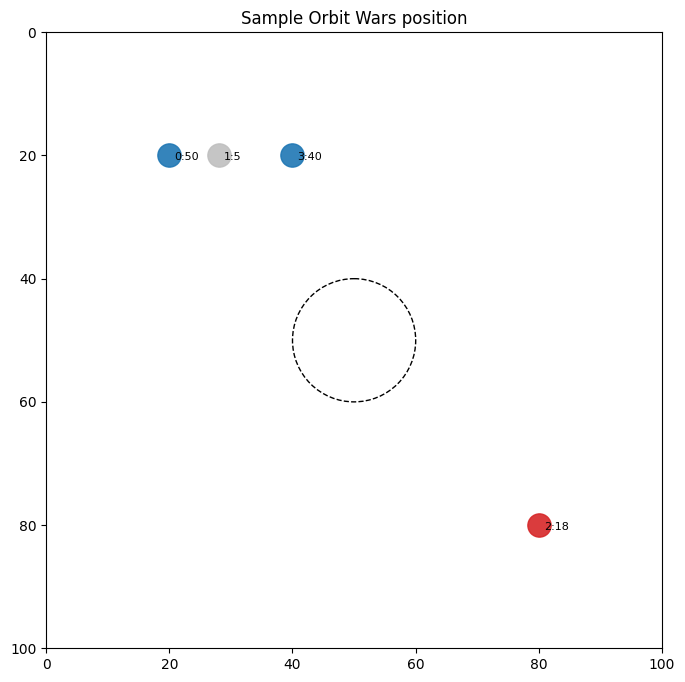

In [3]:
def render_state(obs, title="Orbit Wars state"):
    planets = _parse_planets(obs)
    fleets = _parse_fleets(obs)
    player = _player_id(obs)
    comet_set = _comet_ids(obs)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(100, 0)
    ax.set_aspect("equal", adjustable="box")
    ax.add_artist(plt.Circle((CX, CY), SUN_RADIUS, fill=False, linestyle="--"))
    ax.set_title(title)
    for p in planets:
        owner = int(p.owner)
        if owner == player:
            color = "tab:blue"
        elif owner == -1:
            color = "0.75"
        else:
            color = "tab:red"
        if int(p.id) in comet_set:
            color = "gold" if owner == -1 else color
        ax.scatter([p.x], [p.y], s=max(35, p.radius * 140), c=color, alpha=0.9)
        ax.text(p.x + 0.8, p.y + 0.8, f"{p.id}:{p.ships}", fontsize=8)
    for f in fleets:
        color = "tab:blue" if int(f.owner) == player else "tab:red"
        ax.scatter([f.x], [f.y], s=max(20, math.sqrt(int(f.ships)) * 18), c=color, marker="x")
    plt.show()

print("Orbit Wars notebook loaded successfully.")

sample_obs = {
    "player": 0,
    "planets": [
        [0, 0, 20.0, 20.0, 2.0, 50, 3],
        [1, -1, 28.0, 20.0, 2.0, 5, 1],
        [2, 1, 80.0, 80.0, 2.0, 18, 4],
        [3, 0, 40.0, 20.0, 2.0, 40, 2],
    ],
    "fleets": [],
    "angular_velocity": 0.03,
    "comet_planet_ids": [],
}

demo_action = agent(sample_obs)
print("Example action:", demo_action)
render_state(sample_obs, title="Sample Orbit Wars position")

In [4]:
try:
    from kaggle_environments import make
    env = make("orbit_wars", debug=True)
    env.run([agent, "random"])
    final = env.steps[-1]
    summary = [(i, getattr(s, "reward", None), getattr(s, "status", None)) for i, s in enumerate(final)]
    print("Smoke test results:", summary)
except Exception as e:
    print("Smoke test skipped or unavailable in this runtime:")
    print(type(e).__name__ + ":", e)

Smoke test skipped or unavailable in this runtime:
InvalidArgument: Unknown Environment Specification


## What this bot does

- Predicts orbiting planet positions by rotating them around the sun from their current state.
- Chooses targets using a value model that weighs production, garrison, travel time, and ownership.
- Keeps a reserve on every owned planet so the bot does not empty itself defensively.
- Checks launch paths against the sun before firing.
- Treats comets as opportunistic targets when they are actually worth the travel time.
- Includes a visible demo cell so the notebook shows useful output immediately after running.